In [13]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec

from fiat_toolbox.well_being import CommunityUnit, WellBeingConfig, CapitalStock, IncomeConfig, SimulationConfig, Liquidity

In [14]:
housing_stock = CapitalStock(v=0.7, k=60000)
income_config = IncomeConfig(i_0=48000, i_avg=48000, pi=0.15, c_i_ratio=1.0)
sim_config = SimulationConfig(eta=1.5, rho=0.06, t_max=10, dt=1/52, currency="$", c_min=0.0, recovery_per=95.0)
liq = Liquidity(savings=0)

config = WellBeingConfig(
    housing=housing_stock,
    income=income_config,
    simulation=sim_config,
    liquidity=liq
    
)

In [15]:
# Create a WellBeing object and optimize the lambda value
household = CommunityUnit(config=config)
household

CommunityUnit(
  housing = k=60000.0 v=0.7 recovery_time=None recovery_rate=None,
  rental_housing = None,
  labour_assets = None,
  income = i_0=48000.0 i_avg=48000.0 pi=0.15 c_L=None c_i_ratio=1.0 i_div=None,
  liquidity = savings=0.0 insurance=0.0 support=0.0,
  simulation = eta=1.5 rho=0.06 t_max=10.0 dt=0.019230769230769232 currency='$' c_min=0.0 recovery_per=95.0
)

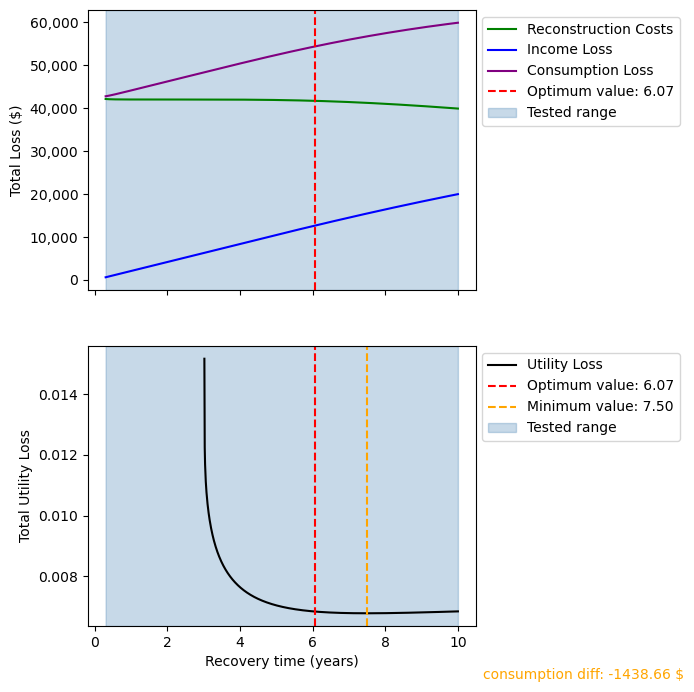

In [16]:
household.opt_lambda(method="trapezoid")
household.plot_opt_lambda(x_type="time");

In [17]:
household.get_losses("trapezoid")

Reconstruction Costs    41698.285717
Income Loss             12674.477869
Consumption Loss        54372.763585
Utility Loss                0.006833
Wellbeing Loss          65263.806022
Asset Loss              42000.000000
Equity Weighted Loss    42000.000000
dtype: float64

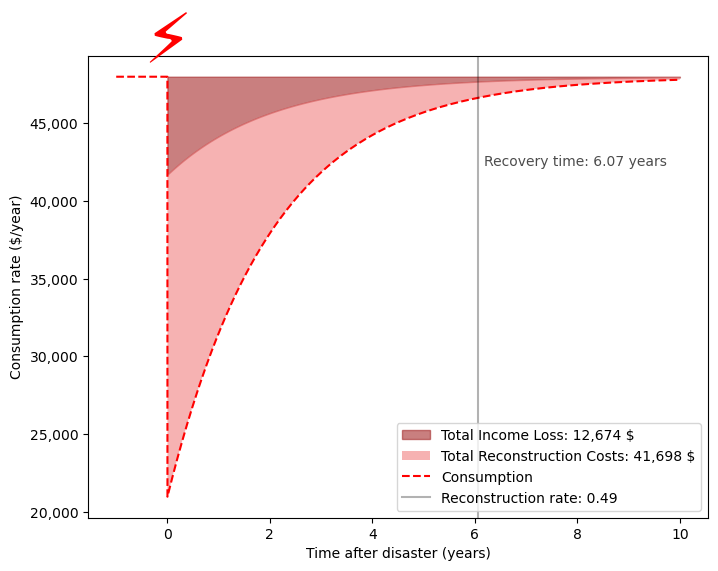

In [18]:
household.plot_consumption()